In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Paths (adjust if needed)
MODEL_PATH = "../models/xception_dr.h5"
TEST_DIR = "../data/testing"
IMAGE_SIZE = (299, 299)
BATCH_SIZE = 32


In [4]:
model = load_model(MODEL_PATH)
model.summary()




Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 299, 299, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 149, 149, 32)         864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 149, 149, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  (None, 149, 149, 32)         0         ['block1_conv1_bn[0][0]'

In [5]:
test_datagen = ImageDataGenerator(
    preprocessing_function=None,
    rescale=1.0/255
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", test_generator.class_indices)


Found 734 images belonging to 5 classes.
Class indices: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


In [6]:
loss, acc = model.evaluate(test_generator, verbose=1)
print("Test Loss:", loss)
print("Test Accuracy:", acc)



23/23 [==============================] - 54s 2s/step - loss: 0.7414 - accuracy: 0.7248
Test Loss: 0.741388738155365
Test Accuracy: 0.7247956395149231


In [7]:
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))


23/23 [==============================] - 52s 2s/step
              precision    recall  f1-score   support

           0       0.78      1.00      0.88       361
           1       0.38      0.07      0.11        74
           2       0.62      0.77      0.69       200
           3       0.88      0.18      0.30        39
           4       0.86      0.10      0.18        60

    accuracy                           0.72       734
   macro avg       0.70      0.42      0.43       734
weighted avg       0.71      0.72      0.66       734



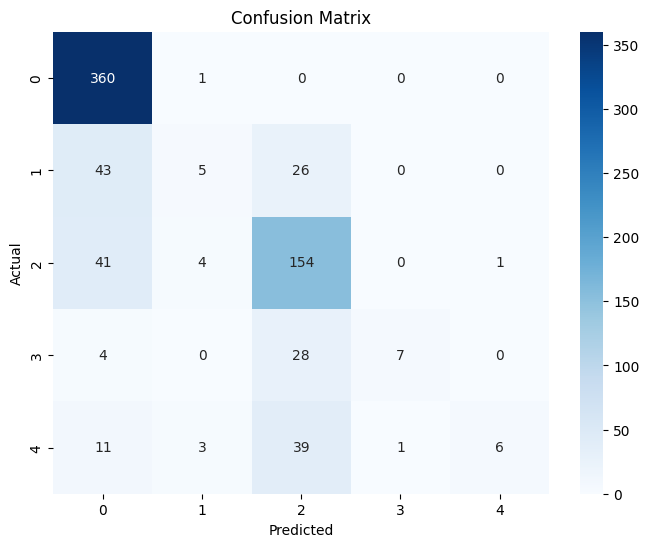

In [8]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [9]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(class_names, per_class_acc):
    print(cls, "accuracy:", round(acc, 4))


0 accuracy: 0.9972
1 accuracy: 0.0676
2 accuracy: 0.77
3 accuracy: 0.1795
4 accuracy: 0.1
